In [1]:
#import necessary module
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc ,recall_score, f1_score, r2_score
from sklearn.model_selection import GridSearchCV

In [3]:
#LOAD DATA
df = pd.read_csv("diabetes_risk.csv")
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               7608 non-null   float64
 1   Glucose                   7586 non-null   float64
 2   BloodPressure             7632 non-null   float64
 3   SkinThickness             7610 non-null   float64
 4   Insulin                   8000 non-null   float64
 5   BMI                       7618 non-null   float64
 6   DiabetesPedigreeFunction  7577 non-null   float64
 7   Age                       7612 non-null   float64
 8   Outcome                   7611 non-null   float64
dtypes: float64(9)
memory usage: 562.6 KB


In [4]:
print("Initial Shape:", df.shape)
print("Columns:", df.columns)

Initial Shape: (8000, 9)
Columns: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [7]:
#REPLACE ZERO WITH NaN
coloumns_with_zero= ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']

for col in coloumns_with_zero:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)

In [5]:
#DATA PREPROCESSING
# HANDLE INVALID VALUES

# Age cannot be <= 0
df.loc[df['Age'] <= 0, 'Age'] = np.nan

# BMI cannot be 0 or negative
df.loc[df['BMI'] <= 0, 'BMI'] = np.nan

# Glucose cannot be 0
if 'Glucose' in df.columns:
    df.loc[df['Glucose'] <= 0, 'Glucose'] = np.nan

# Insulin cannot be 0 (in medical context)
if 'Insulin' in df.columns:
    df.loc[df['Insulin'] <= 0, 'Insulin'] = np.nan

# BloodPressure cannot be 0
if 'BloodPressure' in df.columns:
    df.loc[df['BloodPressure'] <= 0, 'BloodPressure'] = np.nan

# SkinThickness cannot be 0
if 'SkinThickness' in df.columns:
    df.loc[df['SkinThickness'] <= 0, 'SkinThickness'] = np.nan

In [6]:
# REMOVE NEGATIVE VALUES
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df.loc[df[col] < 0, col] = np.nan

In [7]:
# HANDLE MISSING VALUES
# Fill with median (better for medical data)
df.fillna(df.median(numeric_only=True), inplace=True)

In [8]:
# CAP OUTLIERS (Better than removing rows)

def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower, lower, df[column])
    df[column] = np.where(df[column] > upper, upper, df[column])

# Apply safely
columns_to_clean = ['Age', 'BMI']

if 'Glucose' in df.columns:
    columns_to_clean.append('Glucose')
if 'Insulin' in df.columns:
    columns_to_clean.append('Insulin')

for col in columns_to_clean:
    cap_outliers(df, col)


In [9]:
#  FINAL CHECK
print("Final Shape:", df.shape)
print(df.describe())

Final Shape: (8000, 9)
       Pregnancies      Glucose  BloodPressure  SkinThickness      Insulin  \
count  8000.000000  8000.000000    8000.000000    8000.000000  8000.000000   
mean      3.820125   121.510375      72.476125      29.149750   139.517875   
std       3.276753    29.682821      11.835083       8.661406    61.105118   
min       0.000000    44.000000      24.000000       7.000000    14.000000   
25%       1.000000   100.000000      65.000000      26.000000    96.000000   
50%       3.000000   117.000000      72.000000      29.000000   133.000000   
75%       6.000000   139.000000      80.000000      32.000000   176.000000   
max      17.000000   197.500000     122.000000      99.000000   296.000000   

               BMI  DiabetesPedigreeFunction         Age      Outcome  
count  8000.000000               8000.000000  8000.00000  8000.000000  
mean     32.457925                  0.471530    33.06875     0.337250  
std       6.417359                  0.328573    11.31140  

In [10]:
# Count the number of occurrences of each class in the 'Outcome' column
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True) * 100)

Outcome
0.0    5302
1.0    2698
Name: count, dtype: int64
Outcome
0.0    66.275
1.0    33.725
Name: proportion, dtype: float64


In [11]:
#information
df.info

<bound method DataFrame.info of       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             0.0    125.0           72.0           29.0    182.0  22.5   
1             0.0    141.0           72.0           29.0    131.0  42.4   
2            10.0    101.0           86.0           37.0    172.0  45.6   
3             1.0     96.0           72.0           29.0     94.0  22.4   
4             5.0    139.0           64.0           35.0    140.0  28.6   
...           ...      ...            ...            ...      ...   ...   
7995          1.0    117.0           74.0           11.0     60.0  30.0   
7996          3.0     83.0           58.0           31.0     18.0  34.3   
7997          0.0    102.0           86.0           17.0    105.0  29.3   
7998          3.0    124.0           80.0           33.0    130.0  33.2   
7999          1.0    146.0           56.0           29.0    105.0  29.7   

      DiabetesPedigreeFunction   Age  Outcome  
0                  

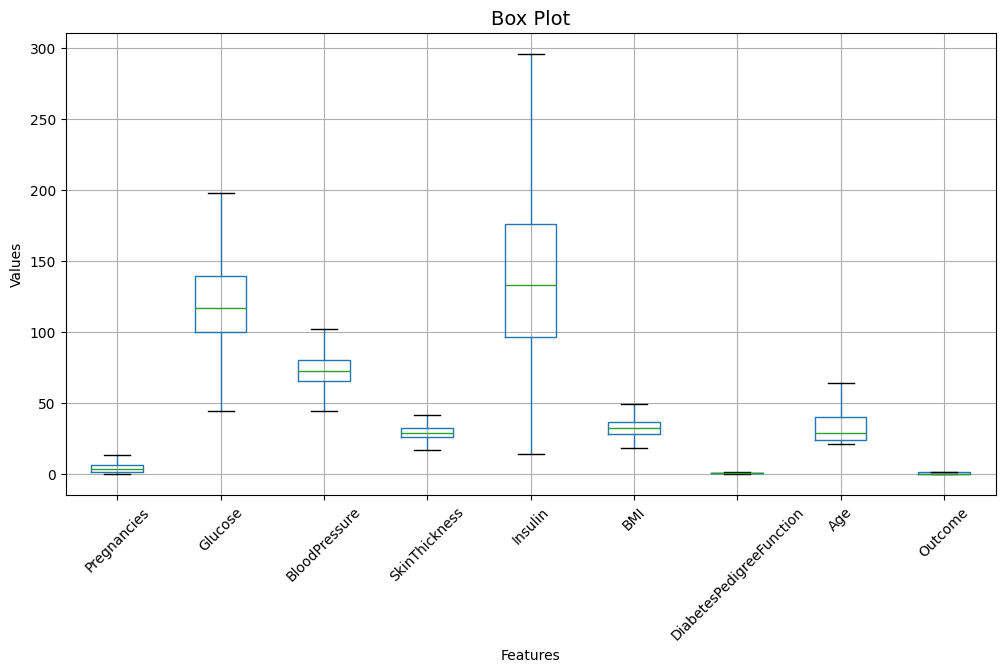

In [12]:
#Shows distribution
plt.figure(figsize=(12,6))

df.boxplot(showfliers=False)

plt.title("Box Plot", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

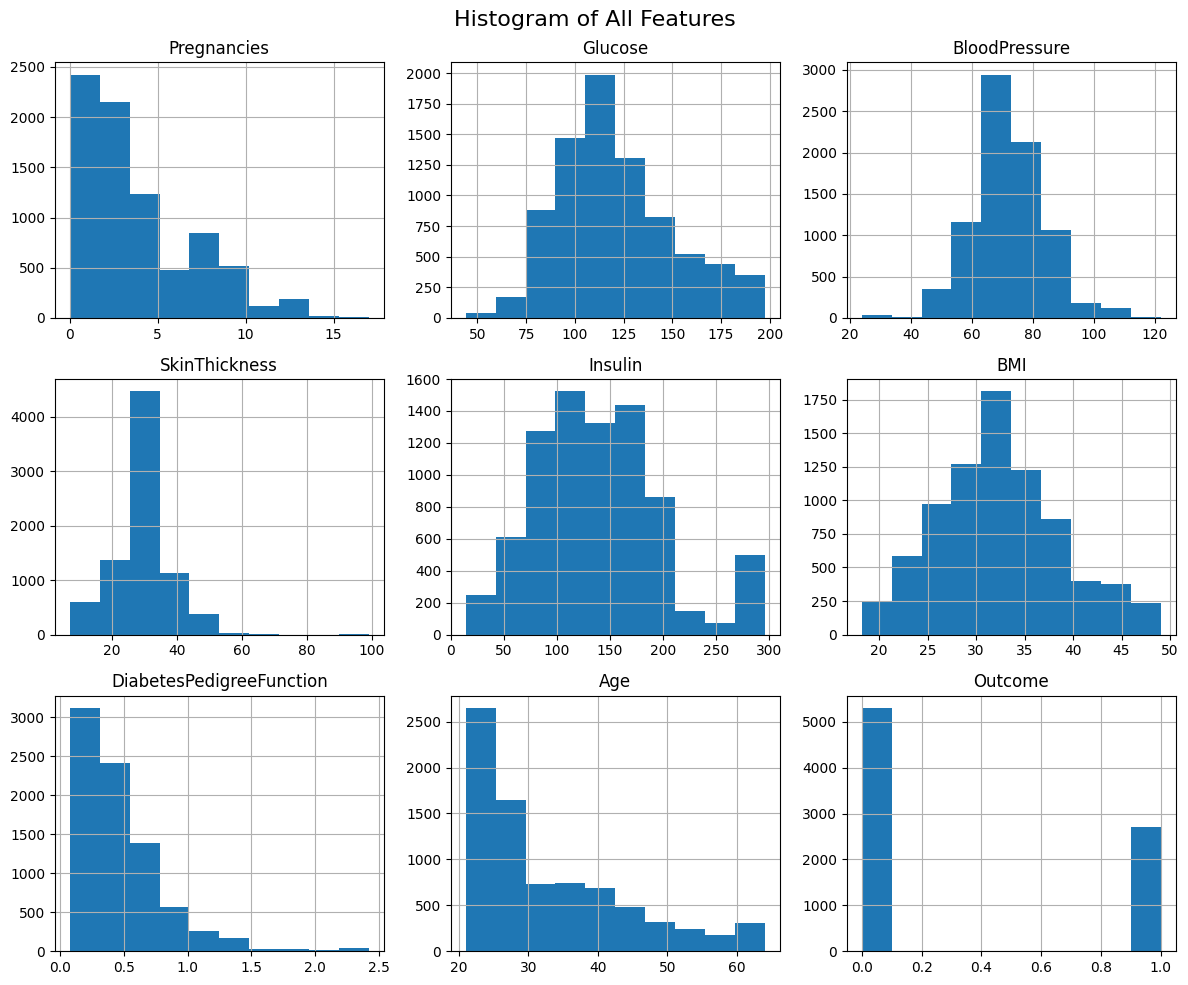

In [13]:
#Shows data distribution and skewness.
df.hist(figsize=(12,10))

plt.suptitle("Histogram of All Features", fontsize=16)

plt.tight_layout()
plt.show()

In [1]:
df_new=pd.read_csv("diabetes_risk.csv")
df_new

NameError: name 'pd' is not defined

In [16]:
#FEATURE SELECTION
# Using ALL columns for maximum predictive power
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [17]:
#SPLIT & SCALE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
#scaling all features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [19]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [20]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [21]:
y_pred = model.predict(X_test_scaled)  

In [22]:
#LOGISTIC REGRESSION
lr= LogisticRegression(class_weight='balanced', max_iter=1000)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [24]:
#DECISION TREE
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

In [25]:
#RANDOM FOREST
rf_model = RandomForestClassifier(max_depth=5, random_state=42)

In [26]:
#GRADIENT BOOSTING
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

In [27]:
#SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)

In [28]:
#ENSEMBLE (VOTING)
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr), 
        ('dt', dt), 
        ('rf', rf_model), 
        ('gb', gb), 
        ('svm', svm)
    ],
    voting='soft' 
)

In [29]:
#ACCURACY CHECKING
print("Model Accuracy Comparison")
models_list = [
    ("Logistic Regression", lr), 
    ("Decision Tree", dt), 
    ("Random Forest", rf_model), 
    ("Gradient Boosting", gb),
    ("SVM", svm),
    ("Ensemble (Final)", ensemble)
]

for name, model in models_list:
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name}: {acc:.2%}")

Model Accuracy Comparison
Logistic Regression: 73.31%
Decision Tree: 81.06%
Random Forest: 82.25%
Gradient Boosting: 87.88%
SVM: 83.56%
Ensemble (Final): 84.31%


In [30]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, fbeta_score, r2_score

print("\n Model Performance Comparison\n")

results = []

models_list = [
    ("Logistic Regression", lr), 
    ("Decision Tree", dt), 
    ("Random Forest", rf_model), 
    ("Gradient Boosting", gb),
    ("SVM", svm),
    ("Ensemble", ensemble)
]

for name, model in models_list:
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    r2 = r2_score(y_test, y_pred)
    


 Model Performance Comparison



In [31]:
print("\n Model Performance Comparison\n")

results = []

models_list = [
    ("Logistic Regression", lr), 
    ("Decision Tree", dt), 
    ("Random Forest", rf_model), 
    ("Gradient Boosting", gb),
    ("SVM", svm),
    ("Ensemble", ensemble)
]

for name, model in models_list:
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results.append([name, acc, recall, f1, f2, r2])
    
    # Print nicely
    print(f"{name}")
    print(f" Accuracy : {acc:.2%}")
    print(f" Recall   : {recall:.2%}")
    print(f" F1 Score : {f1:.2%}")
    print(f" F2 Score : {f2:.2%}")
    print(f" R2 Score : {r2:.2f}")
    print("-" * 40)


 Model Performance Comparison

Logistic Regression
 Accuracy : 73.31%
 Recall   : 71.67%
 F1 Score : 64.45%
 F2 Score : 68.59%
 R2 Score : -0.19
----------------------------------------
Decision Tree
 Accuracy : 81.06%
 Recall   : 64.07%
 F1 Score : 69.55%
 F2 Score : 66.16%
 R2 Score : 0.15
----------------------------------------
Random Forest
 Accuracy : 82.25%
 Recall   : 58.52%
 F1 Score : 69.00%
 F2 Score : 62.30%
 R2 Score : 0.21
----------------------------------------
Gradient Boosting
 Accuracy : 87.88%
 Recall   : 78.52%
 F1 Score : 81.38%
 F2 Score : 79.64%
 R2 Score : 0.46
----------------------------------------
SVM
 Accuracy : 83.56%
 Recall   : 68.52%
 F1 Score : 73.78%
 F2 Score : 70.53%
 R2 Score : 0.26
----------------------------------------
Ensemble
 Accuracy : 84.31%
 Recall   : 70.00%
 F1 Score : 75.07%
 F2 Score : 71.95%
 R2 Score : 0.30
----------------------------------------


In [32]:
# Convert to DataFrame for easy comparison
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Recall", "F1", "F2", "R2"])

print("\n  Summary Table:")
print(results_df)


  Summary Table:
                 Model  Accuracy    Recall        F1        F2        R2
0  Logistic Regression  0.733125  0.716667  0.644463  0.685927 -0.193571
1        Decision Tree  0.810625  0.640741  0.695477  0.661568  0.153040
2        Random Forest  0.822500  0.585185  0.689956  0.623028  0.206150
3    Gradient Boosting  0.878750  0.785185  0.813820  0.796394  0.457722
4                  SVM  0.835625  0.685185  0.737787  0.705299  0.264850
5             Ensemble  0.843125  0.700000  0.750745  0.719452  0.298393


In [33]:
# Hyperparameter Tuning
tuned_models = []

In [34]:
# 1. Logistic Regression

lr_params = {'C': [0.01, 0.1, 1, 10]}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=3,
    scoring='recall'
)
lr_grid.fit(X_train_scaled, y_train)
lr_tuned = lr_grid.best_estimator_
tuned_models.append(("Logistic Regression Tuned", lr_tuned))

In [35]:
# 2. Decision Tree

dt_params = {'max_depth': [3, 5, 10]}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=3,
    scoring='recall'
)
dt_grid.fit(X_train_scaled, y_train)
dt_tuned = dt_grid.best_estimator_
tuned_models.append(("Decision Tree Tuned", dt_tuned))

In [36]:
# 3. Random Forest

rf_params = {'n_estimators': [100, 150], 'max_depth': [5, 10]}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=3,
    scoring='recall'
)
rf_grid.fit(X_train_scaled, y_train)
rf_tuned = rf_grid.best_estimator_
tuned_models.append(("Random Forest Tuned", rf_tuned))

In [37]:
# 4. Gradient Boosting
gb_params = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1]}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=3,
    scoring='recall'
)
gb_grid.fit(X_train_scaled, y_train)
gb_tuned = gb_grid.best_estimator_
tuned_models.append(("Gradient Boosting Tuned", gb_tuned))

In [38]:
# 5. SVM

svm_params = {'C': [0.1, 1, 10], 'kernel': ['rbf']}
svm_grid = GridSearchCV(
    SVC(probability=True),
    svm_params,
    cv=3,
    scoring='recall'
)
svm_grid.fit(X_train_scaled, y_train)
svm_tuned = svm_grid.best_estimator_
tuned_models.append(("SVM Tuned", svm_tuned))

In [40]:
#Evaluate ALL tuned models

print("\n Tuned Model Performance\n")

for name, model in tuned_models:
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"{name}")
    print(f" Accuracy : {acc:.2%}")
    print(f" Recall   : {recall:.2%}")
    print(f" F1 Score : {f1:.2%}")
    print("-" * 40)


 Tuned Model Performance

Logistic Regression Tuned
 Accuracy : 75.75%
 Recall   : 52.59%
 F1 Score : 59.41%
----------------------------------------
Decision Tree Tuned
 Accuracy : 89.25%
 Recall   : 81.48%
 F1 Score : 83.65%
----------------------------------------
Random Forest Tuned
 Accuracy : 94.31%
 Recall   : 91.30%
 F1 Score : 91.55%
----------------------------------------
Gradient Boosting Tuned
 Accuracy : 89.94%
 Recall   : 82.78%
 F1 Score : 84.74%
----------------------------------------
SVM Tuned
 Accuracy : 85.75%
 Recall   : 78.15%
 F1 Score : 78.73%
----------------------------------------


In [43]:
best_model = rf_tuned  

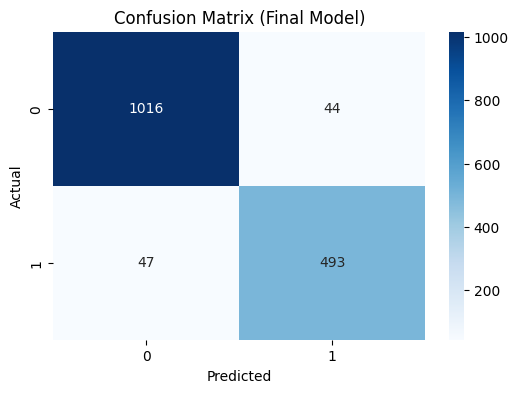

In [44]:
# Visualize with Confusion Matrix
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (Final Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


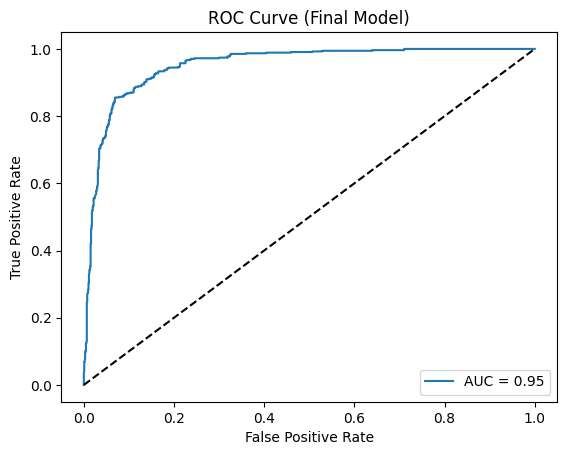

In [45]:
#ROC Curve
best_model = gb_tuned   # or whichever is best
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Final Model)")
plt.legend()
plt.show()


In [46]:
# BEST MODEL = RANDOM FOREST (after tuning)
best_model = rf_tuned 

import pickle

# Save model
with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Random Forest model saved successfully")


Random Forest model saved successfully
